In [1]:
# Naive Bayes con dataset real Iris y gráficos

import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:

# Cargar el conjunto de datos Iris
iris = datasets.load_iris()
X = iris.data[:, :2]  # Usamos solo las dos primeras características para graficar (longitud y anchura del sépalo)
y = iris.target

In [3]:
# Dividir datos en entrenamiento y prueba (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [4]:
# Crear y entrenar el modelo Gaussian Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [5]:
# Predecir en el conjunto de prueba y calcular accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy en conjunto de prueba: {accuracy:.2f}')


Accuracy en conjunto de prueba: 0.82


In [6]:
# Crear un grid  para graficar la frontera de decisión usando todo el rango de los datos
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))


In [7]:
# Predecir la clase para cada punto del grid (para graficar frontera)
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

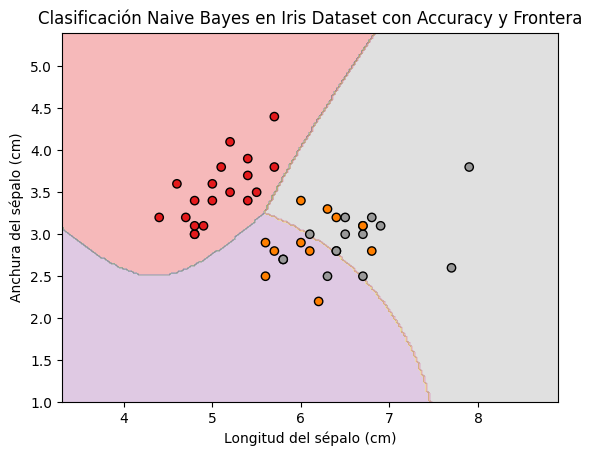

In [8]:
# Graficar la frontera de decisión con color sutil
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set1)

# Graficar los puntos originales de prueba con distinto color para cada especie
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor='k', cmap=plt.cm.Set1)
plt.xlabel('Longitud del sépalo (cm)')
plt.ylabel('Anchura del sépalo (cm)')
plt.title('Clasificación Naive Bayes en Iris Dataset con Accuracy y Frontera')
plt.show()

Ejemplo con Titanic, para clasificar si un pasajero sobrevivió usando Naive Bayes. Incluye preprocesamiento básico, entrenamiento y evaluación del modelo.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [10]:
# URL directa al archivo Titanic CSV
url = "https://github.com/datasciencedojo/datasets/raw/master/titanic.csv"

# Cargar el dataset directamente en pandas
df = pd.read_csv(url)

# Mostrar las primeras filas
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [11]:
# Preprocesamiento básico

# Rellenar valores faltantes de Age con la mediana
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipykernel_177082/335754514.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].median(), inplace=True)


0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [12]:

# Convertir campo Sexo a valores numéricos (male=0, female=1)
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

In [13]:
# Eliminar columnas no usadas para simplificar
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

In [14]:
# Dividir en características y variable objetivo
X = df.drop('Survived', axis=1)
y = df['Survived']

In [15]:
# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [16]:
# Entrenar modelo Naive Bayes Gaussiano
model = GaussianNB()
model.fit(X_train, y_train)

ValueError: Input X contains NaN.
GaussianNB does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# Predecir con el conjunto de prueba
y_pred = model.predict(X_test)


In [ ]:
# Evaluar precisión
acc = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {acc:.2f}')


Precisión del modelo: 0.78


In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print('Matriz de confusión:')
print(cm)

Matriz de confusión:
[[126  31]
 [ 29  82]]


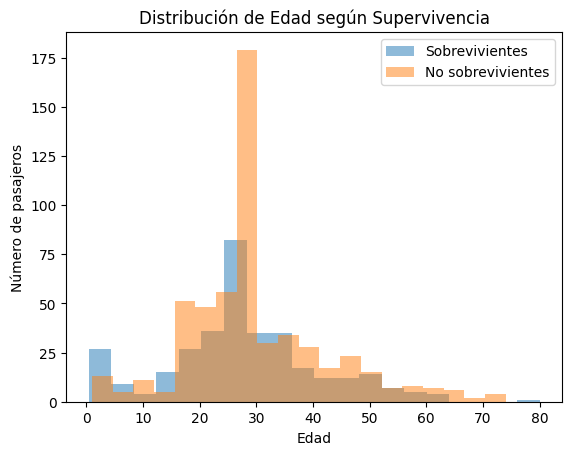

In [ ]:
# Visualización simple - distribución de edades para sobrevivientes y no sobrevivientes
plt.hist(df[df['Survived'] == 1]['Age'], bins=20, alpha=0.5, label='Sobrevivientes')
plt.hist(df[df['Survived'] == 0]['Age'], bins=20, alpha=0.5, label='No sobrevivientes')
plt.xlabel('Edad')
plt.ylabel('Número de pasajeros')
plt.title('Distribución de Edad según Supervivencia')
plt.legend()
plt.show()